# 3D peptide-binding pocket with CDR overlay

Interactive [py3Dmol](https://3dmol.csb.pitt.edu/) view (histo.fyi-style) of the MHC groove with
the peptide and the overlaid TCR CDR1-3 loops, in the canonical (oriented) frame. The py3Dmol
widget is interactive in a live Jupyter kernel; the static docs build cannot render the widget, so
a matplotlib snapshot of the same oriented interface is shown at the end as a fallback.

In [1]:
# Load + annotate a native complex
from tcren.structure import parse_structure
from tcren.annotation import classify_chains
from tcren.mhc import annotate_mhc

structure = parse_structure('data/Native2026/1ao7.pdb.gz', pdb_id='1ao7')
classify_chains(structure, organism='human')
annotate_mhc(structure)

[MhcCall(chain_id='D', chain_role='MHCa', mhc_class='MHCI', allele='HLA-A*02:1219N', locus='A', species='human', identity=100.0, bits=596.0, qstart=1, qend=274, tstart=25, tend=298, cigar='274M'),
 MhcCall(chain_id='E', chain_role='B2M', mhc_class='MHCI', allele='B2M', locus='B2M', species='human', identity=97.9, bits=212.0, qstart=1, qend=99, tstart=21, tend=119, cigar='99M')]

In [2]:
# Interactive view: MHC groove (cartoon+surface), peptide sticks, CDR1-3 Ca loops (live kernel only)
from tcren.viz import view_pocket_cdr

view = view_pocket_cdr(structure, surface=True)
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Static fallback (matplotlib 3D)

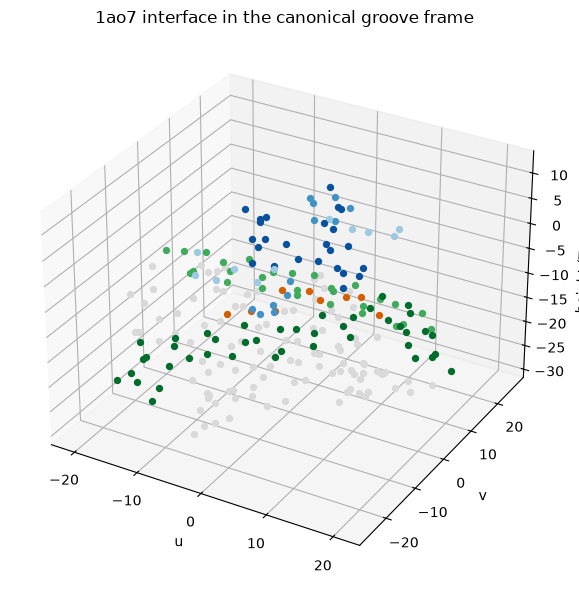

In [3]:
# Static 3D snapshot of the oriented interface, colored by region (renders in static docs)
%matplotlib inline
import matplotlib.pyplot as plt
import polars as pl
from tcren.project2d import project_structure, residue_markup_table
from tcren.viz.palette import color_for

projection = project_structure(structure)
markup = residue_markup_table(structure, projection).filter(pl.col('x').is_not_null())

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
for row in markup.iter_rows(named=True):
    ax.scatter(row['x'], row['y'], row['z'],
               color=color_for(row['complex_chain'], row['complex_region']), s=18)
ax.set_xlabel('u'); ax.set_ylabel('v'); ax.set_zlabel('height (TCR up)')
ax.set_title('1ao7 interface in the canonical groove frame')
plt.tight_layout()
plt.show()